# 01. Entendimiento del Dato

## Qué estoy intentando lograr

En este cuaderno mi objetivo no es “mirar unos CSV” de forma superficial. Lo que busco es entender con rigor qué representa realmente el dataset, cuál es su unidad analítica correcta y qué sería irresponsable prometer después en el producto.

Como AI engineer, me interesa demostrar algo muy concreto: antes de pensar en modelos, chat o visualizaciones llamativas, primero me obligo a leer el dato con honestidad.


## Cómo me estoy planteando el problema

Cuando recibo un dataset para una prueba así, me hago estas preguntas en este orden:

1. ¿Qué forma real tiene el dato?
2. ¿Qué granularidad soporta y cuál no?
3. ¿Qué problemas de calidad pueden distorsionar una lectura rápida?
4. ¿Qué parte de la historia del negocio puedo defender con evidencia?
5. ¿Cómo condiciona esto al dashboard y al bot?

Si no cierro esto primero, cualquier arquitectura o chatbot que construya después nace sobre supuestos frágiles.


## Qué no voy a asumir de entrada

- No asumiré que hay una fila por tienda.
- No asumiré que el nombre de la métrica ya me da definición de negocio completa.
- No asumiré continuidad perfecta del histórico solo porque haya muchos archivos.
- No asumiré que los archivos están listos para usarse directamente en producto.


In [12]:
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib"))
sys.path.insert(0, str(ROOT / "scripts"))

import matplotlib.pyplot as plt
import pandas as pd

from process_availability_data import (
    annotate_windows,
    build_canonical_series,
    load_raw_windows_and_points,
)

RAW_DIR = ROOT / "data" / "raw"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
plt.style.use("default")


## 1. Cargo el raw en dos niveles

Primero separo el problema en dos vistas:

- una vista de **ventanas** (`windows_df`), para entender cómo viene exportado cada archivo,
- una vista de **puntos crudos** (`raw_points_df`), para después ver si puedo construir una serie canónica confiable.

Hago esto porque muchas veces el problema no está solo en los valores, sino en cómo están particionados y exportados.


In [13]:
# Cargo los archivos raw y anoto metadata de calidad a nivel ventana.
raw_windows_df, raw_points_df = load_raw_windows_and_points(RAW_DIR)
windows_df = annotate_windows(raw_windows_df)

# También construyo una primera versión canónica para verificar solapes.
canonical_df = build_canonical_series(windows_df, raw_points_df)

print(f"Archivos raw: {len(windows_df):,}")
print(f"Registros raw a nivel timestamp (con solapes): {len(raw_points_df):,}")
print(f"Timestamps canónicos únicos: {len(canonical_df):,}")


Archivos raw: 201
Registros raw a nivel timestamp (con solapes): 69,128
Timestamps canónicos únicos: 67,141


/Users/tomasvelasquez/Desktop/RappiAi/ai-powered-dashboard/scripts/process_availability_data.py:192: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  canonical["hour_bucket"] = pd.to_datetime(canonical["timestamp"]).dt.floor("H")


Lo primero que me interesa validar aquí es si el volumen del raw se colapsa de forma limpia a una serie única o si aparecen contradicciones. Si no pudiera construir una serie canónica sin conflictos, eso me frenaría todo el proyecto.


## 2. ¿Qué estructura real tiene el dataset?

Aquí quiero contestar algo muy básico pero decisivo: ¿estoy frente a una tabla analítica por entidad o frente a una serie agregada exportada por ventanas?


In [14]:
# Resumo la forma dominante del dataset para identificar su “contrato” de facto.
schema_summary = pd.DataFrame(
    {
        "metric_name_mode": [windows_df["metric_name"].mode().iloc[0]],
        "plot_name_mode": [windows_df["plot_name"].mode().iloc[0]],
        "source_files": [len(windows_df)],
        "unique_window_fingerprints": [windows_df["window_fingerprint"].nunique()],
        "point_count_mode": [int(windows_df["point_count"].mode().iloc[0])],
        "cadence_seconds_mode": [int(windows_df["cadence_seconds"].mode().iloc[0])],
        "window_duration_mode_seconds": [int(windows_df["window_duration_seconds"].mode().iloc[0])],
    }
)

schema_summary


,metric_name_mode,plot_name_mode,source_files,unique_window_fingerprints,point_count_mode,cadence_seconds_mode,window_duration_mode_seconds
0,synthetic_monitoring_visible_stores,NOW,201,197,363,10,3620


Al ver esta tabla, mi lectura no es “qué buena pinta tiene”, sino:

- si la métrica dominante es única,
- si la cadencia es estable,
- si la duración de ventana es razonablemente consistente,
- y si los archivos son realmente observaciones distintas o duplicados con otro nombre.


In [15]:
# Miro una muestra de ventanas para aterrizar la intuición con evidencia concreta.
windows_df[
    [
        "source_file",
        "window_start",
        "window_end",
        "point_count",
        "cadence_seconds",
        "window_duration_seconds",
        "first_value",
        "last_value",
        "min_value",
        "max_value",
    ]
].head(12)


,source_file,window_start,window_end,point_count,cadence_seconds,window_duration_seconds,first_value,last_value,min_value,max_value
0,AVAILABILITY-data.csv,2026-02-01 06:11:20-05:00,2026-02-01 07:00:00-05:00,293,10,2920,37,18751,37,20762
1,AVAILABILITY-data (1).csv,2026-02-01 06:59:40-05:00,2026-02-01 08:00:00-05:00,363,10,3620,18647,39745,18647,39771
2,AVAILABILITY-data (2).csv,2026-02-01 07:59:40-05:00,2026-02-01 09:00:00-05:00,363,10,3620,39771,424536,39745,425546
3,AVAILABILITY-data (3).csv,2026-02-01 08:59:40-05:00,2026-02-01 10:00:00-05:00,363,10,3620,424265,1231534,424265,1282681
4,AVAILABILITY-data (4).csv,2026-02-01 09:59:40-05:00,2026-02-01 11:00:00-05:00,363,10,3620,1231899,2039683,1228440,2056874
5,AVAILABILITY-data (5).csv,2026-02-01 10:59:40-05:00,2026-02-01 12:00:00-05:00,363,10,3620,2039594,2725656,2038633,2731352
6,AVAILABILITY-data (6).csv,2026-02-01 11:59:40-05:00,2026-02-01 13:00:00-05:00,363,10,3620,2731352,3466178,2725656,3488777
7,AVAILABILITY-data (7).csv,2026-02-01 12:59:40-05:00,2026-02-01 14:00:00-05:00,363,10,3620,3466890,4343596,3466178,4386731
8,AVAILABILITY-data (8).csv,2026-02-01 13:59:40-05:00,2026-02-01 15:00:00-05:00,363,10,3620,4340908,5036598,4340908,5059827
9,AVAILABILITY-data (9).csv,2026-02-01 14:59:40-05:00,2026-02-01 16:00:00-05:00,363,10,3620,5032942,5168418,5026136,5224516


Esta preview me ayuda a razonar mejor: no veo entidades de negocio, veo exportaciones temporales. Eso ya me mueve mentalmente desde “dashboard por tienda” hacia “analytics sobre una señal agregada”.


## 3. ¿Qué tan limpio viene el raw?

Antes de derivar métricas, quiero aislar tres problemas concretos:

- duplicados exactos,
- ventanas incompletas,
- solapes entre archivos.

Si no los trato, cualquier KPI o respuesta del bot podría salir inflada, sesgada o mal explicada.


In [16]:
quality_snapshot = pd.DataFrame(
    {
        "duplicate_window_groups": [windows_df.loc[windows_df["is_duplicate_window"], "window_fingerprint"].nunique()],
        "duplicate_window_records": [int(windows_df["is_duplicate_window"].sum())],
        "incomplete_window_records": [int(windows_df["is_incomplete_window"].sum())],
        "overlapping_timestamps": [int((canonical_df["timestamp_occurrences"] > 1).sum())],
        "conflicting_timestamps": [int(canonical_df["has_conflicting_values"].sum())],
    }
)

quality_snapshot


,duplicate_window_groups,duplicate_window_records,incomplete_window_records,overlapping_timestamps,conflicting_timestamps
0,4,8,27,1963,0


Lo que más me importa aquí no es solo contar problemas, sino clasificar su gravedad:

- un duplicado exacto es molesto, pero tratable,
- una ventana incompleta exige cuidado en interpretación,
- un conflicto de valor para el mismo timestamp sería mucho más grave.

Si los solapes no tienen conflicto, puedo deduplicar con confianza. Si lo tuvieran, tendría que diseñar reconciliación adicional.


In [17]:
# Reviso explícitamente las ventanas duplicadas para entender si son ruido administrativo o un problema lógico.
duplicate_windows = windows_df.loc[
    windows_df["is_duplicate_window"],
    [
        "source_file",
        "window_start",
        "window_end",
        "point_count",
        "duplicate_group_size",
        "duplicate_rank",
    ],
].sort_values(["window_start", "duplicate_rank"])

duplicate_windows


,source_file,window_start,window_end,point_count,duplicate_group_size,duplicate_rank
40,AVAILABILITY-data (40).csv,2026-02-03 07:59:40-05:00,2026-02-03 09:00:00-05:00,363,2,1
41,AVAILABILITY-data (41).csv,2026-02-03 07:59:40-05:00,2026-02-03 09:00:00-05:00,363,2,2
79,AVAILABILITY-data (79).csv,2026-02-05 08:59:40-05:00,2026-02-05 10:00:00-05:00,363,2,1
80,AVAILABILITY-data (80).csv,2026-02-05 08:59:40-05:00,2026-02-05 10:00:00-05:00,363,2,2
105,AVAILABILITY-data - 2026-02-11T160010.761.csv,2026-02-06 14:59:40-05:00,2026-02-06 16:00:00-05:00,363,2,1
106,AVAILABILITY-data - 2026-02-11T160224.727.csv,2026-02-06 14:59:40-05:00,2026-02-06 16:00:00-05:00,363,2,2
160,AVAILABILITY-data - 2026-02-11T162528.931.csv,2026-02-09 12:59:40-05:00,2026-02-09 14:00:00-05:00,363,2,1
161,AVAILABILITY-data - 2026-02-11T162838.106.csv,2026-02-09 12:59:40-05:00,2026-02-09 14:00:00-05:00,363,2,2


In [18]:
# También inspecciono las ventanas incompletas para ver si son solo bordes del día o truncamientos intradía reales.
incomplete_windows = windows_df.loc[
    windows_df["is_incomplete_window"],
    [
        "source_file",
        "window_start",
        "window_end",
        "point_count",
        "window_duration_seconds",
        "cadence_seconds",
    ],
].sort_values("window_start")

incomplete_windows.head(25)


,source_file,window_start,window_end,point_count,window_duration_seconds,cadence_seconds
0,AVAILABILITY-data.csv,2026-02-01 06:11:20-05:00,2026-02-01 07:00:00-05:00,293,2920,10
18,AVAILABILITY-data (18).csv,2026-02-01 23:59:40-05:00,2026-02-02 00:06:20-05:00,41,400,10
19,AVAILABILITY-data (19).csv,2026-02-02 06:11:20-05:00,2026-02-02 07:00:00-05:00,293,2920,10
32,AVAILABILITY-data (32).csv,2026-02-02 19:00:00-05:00,2026-02-02 20:00:00-05:00,361,3600,10
36,AVAILABILITY-data (36).csv,2026-02-02 23:08:50-05:00,2026-02-03 00:00:00-05:00,308,3070,10
37,AVAILABILITY-data (37).csv,2026-02-02 23:59:40-05:00,2026-02-03 00:06:30-05:00,42,410,10
38,AVAILABILITY-data (38).csv,2026-02-03 06:11:20-05:00,2026-02-03 07:00:00-05:00,293,2920,10
39,AVAILABILITY-data (39).csv,2026-02-03 07:06:40-05:00,2026-02-03 08:00:00-05:00,321,3200,10
57,AVAILABILITY-data (57).csv,2026-02-03 23:59:40-05:00,2026-02-04 00:06:20-05:00,41,400,10
58,AVAILABILITY-data (58).csv,2026-02-04 06:11:20-05:00,2026-02-04 07:00:00-05:00,293,2920,10


Aquí mi lectura crítica es importante: no toda incompletitud significa lo mismo. Algunas ventanas son cortas por estar en bordes de jornada; otras parecen recortes o huecos reales. Si mezclo ambos casos, contamino la interpretación de cobertura.


In [19]:
# Bajo la calidad al nivel de día para ver si el problema es puntual o estructural.
window_daily = (
    windows_df.groupby("window_day")
    .agg(
        window_files=("source_file", "size"),
        unique_windows=("window_fingerprint", "nunique"),
        incomplete_windows=("is_incomplete_window", "sum"),
        duplicate_records=("is_duplicate_window", "sum"),
        first_window_start=("window_start", "min"),
        last_window_end=("window_end", "max"),
    )
    .reset_index()
)

window_daily


,window_day,window_files,unique_windows,incomplete_windows,duplicate_records,first_window_start,last_window_end
0,2026-02-01,19,19,2,0,2026-02-01 06:11:20-05:00,2026-02-02 00:06:20-05:00
1,2026-02-02,19,19,4,0,2026-02-02 06:11:20-05:00,2026-02-03 00:06:30-05:00
2,2026-02-03,20,19,3,2,2026-02-03 06:11:20-05:00,2026-02-04 00:06:20-05:00
3,2026-02-04,18,18,1,0,2026-02-04 06:11:20-05:00,2026-02-05 00:00:00-05:00
4,2026-02-05,20,19,2,2,2026-02-05 06:11:20-05:00,2026-02-06 00:06:30-05:00
5,2026-02-06,20,19,3,2,2026-02-06 06:11:20-05:00,2026-02-07 00:06:20-05:00
6,2026-02-07,19,19,2,0,2026-02-07 06:11:30-05:00,2026-02-08 00:06:20-05:00
7,2026-02-08,18,18,2,0,2026-02-08 06:11:30-05:00,2026-02-09 00:06:30-05:00
8,2026-02-09,20,19,4,2,2026-02-09 06:11:20-05:00,2026-02-10 00:06:30-05:00
9,2026-02-10,19,19,3,0,2026-02-10 06:11:20-05:00,2026-02-11 00:06:30-05:00


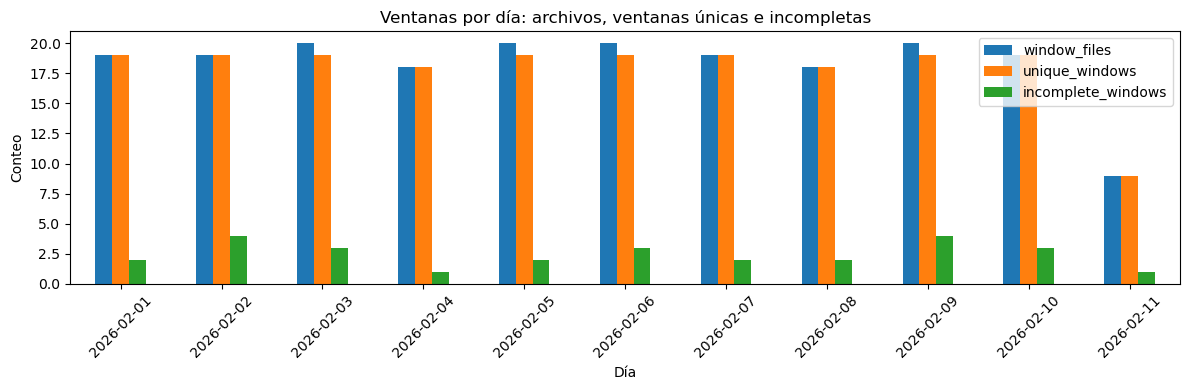

In [20]:
# Lo grafico porque quiero ver rápidamente si hay patrones repetidos por día.
fig, ax = plt.subplots(figsize=(12, 4))
window_daily.plot(
    x="window_day",
    y=["window_files", "unique_windows", "incomplete_windows"],
    kind="bar",
    ax=ax,
    title="Ventanas por día: archivos, ventanas únicas e incompletas",
)
ax.set_xlabel("Día")
ax.set_ylabel("Conteo")
ax.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()


Al mirar esto, ya puedo empezar a hablar no solo de calidad “técnica”, sino de calidad relevante para producto. Si la cobertura y la completitud varían por día, entonces el dashboard y el bot deben exponer advertencias o niveles de confianza.


## 4. ¿Puedo construir una serie canónica confiable?

Esta es probablemente la pregunta más importante del cuaderno. Si los timestamps solapados traen siempre el mismo valor, entonces puedo consolidar una serie única. Si no, tendría una ambigüedad estructural difícil de defender.


In [21]:
# Mido cuántas veces aparece cada timestamp una vez que combino todas las ventanas.
timestamp_multiplicity = (
    canonical_df["timestamp_occurrences"].value_counts().sort_index().rename_axis("occurrences").reset_index(name="timestamps")
)

timestamp_multiplicity


,occurrences,timestamps
0,1,65178
1,2,1939
2,3,24


In [22]:
# Inspecciono un subconjunto de timestamps solapados para ver si hay conflicto real de valor.
canonical_df.loc[
    canonical_df["timestamp_occurrences"] > 1,
    ["timestamp", "value", "timestamp_occurrences", "unique_values", "has_conflicting_values"],
].head(12)


,timestamp,value,timestamp_occurrences,unique_values,has_conflicting_values
290,2026-02-01 06:59:40-05:00,18647,2,1,False
291,2026-02-01 06:59:50-05:00,18846,2,1,False
292,2026-02-01 07:00:00-05:00,18751,2,1,False
650,2026-02-01 07:59:40-05:00,39771,2,1,False
651,2026-02-01 07:59:50-05:00,39770,2,1,False
652,2026-02-01 08:00:00-05:00,39745,2,1,False
1010,2026-02-01 08:59:40-05:00,424265,2,1,False
1011,2026-02-01 08:59:50-05:00,424919,2,1,False
1012,2026-02-01 09:00:00-05:00,424536,2,1,False
1370,2026-02-01 09:59:40-05:00,1231899,2,1,False


Mi criterio aquí es simple: si `has_conflicting_values` es `False` en toda la serie, entonces la deduplicación es defendible y el producto puede trabajar sobre una verdad operacional consistente.

Eso es exactamente lo que quería verificar antes de seguir.


## 5. Qué concluyo y cómo esto redefine el producto

### Lo que me quedó claro

- estoy frente a una **serie temporal agregada**, no un dataset por tienda,
- el raw tiene duplicados e incompletitud, pero no conflictos de valor por timestamp,
- sí puedo construir una serie canónica confiable,
- el principal riesgo no es contradicción del dato, sino cobertura parcial y lectura apresurada.

### Qué implica para el dashboard

- debo mostrar tendencia, patrón horario, cobertura y anomalías,
- no debo inventar dimensiones por tienda,
- necesito badges o señales de confianza cuando la cobertura sea baja.

### Qué implica para el bot

- puede responder preguntas sobre evolución temporal, comparación de períodos, calidad del dato y desvíos frente a baseline,
- no debe prometer answers por tienda, merchant ni causalidad operativa.

Ese cambio de enfoque no me limita. Al contrario: me permite construir una solución mucho más seria y defendible.


## 6. Qué decisiones me llevo al siguiente notebook

Termino este cuaderno con una idea bastante concreta de trabajo. No quiero abrir el notebook 02 para “seguir explorando”, sino para operacionalizar decisiones ya tomadas:

- voy a construir una **serie canónica por timestamp** como fuente de verdad del producto,
- voy a conservar metadata de calidad para que el backend y el bot puedan hablar con contexto,
- no voy a modelar entidades como tiendas, zonas o merchants porque el raw no las soporta,
- voy a privilegiar agregados diarios y horarios porque son los que mejor conectan con dashboard y chatbot,
- voy a tratar duplicidad, gaps e incompletitud como parte del producto, no como un detalle invisible de ETL.

Eso, para mí, es una señal de madurez analítica: no separar el dato de la experiencia final, sino dejar que el dato real defina el alcance del producto.
